In [61]:
import csv
from datetime import datetime

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [62]:
dataset = 'model/keypoint_classifier/keypoint.csv'
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
model_save_path = f'model/keypoint_classifier/keypoint_classifier_{run_id}.keras'
tflite_save_path = f'model/keypoint_classifier/keypoint_classifier_{run_id}.tflite'

# Set number of classes

In [63]:
NUM_CLASSES = 10

# Dataset reading

In [64]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [65]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [67]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [68]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_6 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180 (4.61 KB)

 Trainable params: 1,180 (4.61 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1, restore_best_weights=True)

In [70]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [71]:
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[es_callback]
)
model.save(model_save_path, include_optimizer=False)

Epoch 1/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1535 - loss: 2.2594 - val_accuracy: 0.2557 - val_loss: 2.1254
Epoch 2/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2065 - loss: 2.1156 - val_accuracy: 0.2735 - val_loss: 1.9896
Epoch 3/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2364 - loss: 1.9991 - val_accuracy: 0.3298 - val_loss: 1.8372
Epoch 4/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2790 - loss: 1.8944 - val_accuracy: 0.4801 - val_loss: 1.7006
Epoch 5/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3238 - loss: 1.8063 - val_accuracy: 0.6024 - val_loss: 1.5824
Epoch 6/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3835 - loss: 1.7096 - val_accuracy: 0.6743 - val_loss: 1.4611
Epoch 7/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4192 - loss: 1.6278 - val_accuracy: 0.6921 - val_loss: 1.3486
Epoch 8/1000
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4406 - loss: 1.5635 - val_accuracy: 0

In [72]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8844 - loss: 0.4344 


In [73]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [74]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
[6.9357464e-03 1.3168601e-02 1.0603310e-03 2.1789420e-02 4.4420450e-03
 2.4894476e-07 9.3466687e-01 4.2082150e-03 6.4612203e-04 1.3082518e-02]
6


# Confusion matrix

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


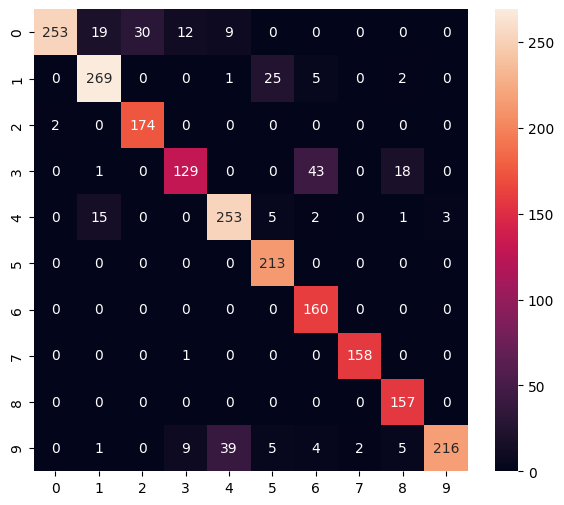

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.78      0.88       323
           1       0.88      0.89      0.89       302
           2       0.85      0.99      0.92       176
           3       0.85      0.68      0.75       191
           4       0.84      0.91      0.87       279
           5       0.86      1.00      0.92       213
           6       0.75      1.00      0.86       160
           7       0.99      0.99      0.99       159
           8       0.86      1.00      0.92       157
           9       0.99      0.77      0.86       281

    accuracy                           0.88      2241
   macro avg       0.89      0.90      0.89      2241
weighted avg       0.89      0.88      0.88      2241



In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [76]:
# Save as a model dedicated to inference
# Already saved immediately after training.

In [77]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\627525\AppData\Local\Temp\tmpthxb_hak\assets


INFO:tensorflow:Assets written to: C:\Users\627525\AppData\Local\Temp\tmpthxb_hak\assets


Saved artifact at 'C:\Users\627525\AppData\Local\Temp\tmpthxb_hak'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1786437941584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1786523950096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1786524147664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1786438087312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1786438087504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1786438082704: TensorSpec(shape=(), dtype=tf.resource, name=None)


6968

# Inference test

In [78]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

c:\Users\627525\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [79]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [80]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [81]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 1.58 ms


In [82]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[6.9357464e-03 1.3168601e-02 1.0603304e-03 2.1789420e-02 4.4420427e-03
 2.4894425e-07 9.3466687e-01 4.2082132e-03 6.4612133e-04 1.3082518e-02]
6
